In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# *Inicializando dataset de videojuegos*

variable datos es un dataframe

In [ ]:
datos = pd.read_csv("data/games.csv", index_col="Id") # 2 parametros(ruta, Indice columna)
datos.head(10) # siempre se utiliza

# *Consultando tipo de dato*

In [ ]:
type(datos)

# *Dimensión del Dataset*

In [ ]:
print(f"Cantidad de filas y columnas del dataset: {datos.shape}")

en el caso anterior, la dimension de dataset games.csv es de 1521 y 13

# *Mostrando informacion del Dataset*

In [ ]:
datos.info()

# *Estadisticas descriptivas*

In [ ]:
datos.describe()

para calcular promedios, max y min

# *Mostrando filas de datos nulos*

In [ ]:
datos.isnull()

# *Identificando columnas con datos nulos*

In [ ]:
columnas_nulas = datos.isnull().any()
columnas_nulas

# El simbolo NaN indica valores nulos

# *Identificando filas en especifico con datos nulos*

In [ ]:
filas_nulas = datos[datos.isnull().any(axis=1)] # Datos es dataframe
filas_nulas

#### **Eliminar datos nulos del dataset**

Importante, Guardar dataset sin nulos dentro de una variable aparte

In [ ]:
datos_sin_nulos= datos.dropna() # Se eliminan las 14 filas
datos_sin_nulos

#### **Función para verificar si genero de videojuegos esta en la lista**

Verificando si está el genero RPG en la lista

In [ ]:
# Funcion que filtra por genero RPG
def filtro_rpg(genres):
    return "RPG" in genres

# Aplicar filtro para consultar y llamar 
datosRPG = datos_sin_nulos[datos_sin_nulos["Genres"].apply(filtro_rpg)] # Creando nuevo dataframe

# Mostrar el dataset filtrado, incluyendo solo columnas (titulo y rating)
nombresRPG = datosRPG[["Title","Rating"]] # Nuevo datafframe
nombresRPG.head(20) #Se muestran los primeros 20

#### **Graficar los primeros 10 videojuegos RPG y su rating de popularidad (Gráfico de barra)**

In [ ]:
GraficoRPG = nombresRPG.head(10)
GraficoRPG

#### **Grafico mal hecho**

In [ ]:
GraficoRPG.drop(["Title"],axis=1)["Rating"].plot(kind="bar")

#### **Agregando titulo al gráfico**

In [ ]:
GraficoRPG = nombresRPG.head(10)
GraficoRPG.set_index("Title", inplace=True)
GraficoRPG["Rating"].plot(kind= "bar")


#### **Agregando etiquetas de graficos**

In [ ]:
GraficoRPG = nombresRPG.head(10)
GraficoRPG.set_index("Title", inplace=True)
graph = GraficoRPG["Rating"].plot(kind= "bar")
for i, rating in enumerate(GraficoRPG["Rating"]):
    graph.annotate(str(rating), xy = (i,rating), ha="center", va = "bottom")
    
plt.show()

#### **Gráfico de torta**

## *Promedio*

In [ ]:
promedioRPG = datosRPG[["Rating"]]
promRPG = promedioRPG.mean()


In [ ]:
promRPG

In [ ]:
def filtro_indie(genres):
    return "Indie" in genres

datosIndie = datos_sin_nulos[datos_sin_nulos["Genres"].apply(filtro_indie)] 

# Mostrar el dataset filtrado, incluyendo solo columnas (titulo y rating)
nombresIndie = datosIndie[["Title","Rating"]] # Nuevo datafframe
nombresIndie.head(20) #Se muestran los primeros 20

In [ ]:
promedioIndie = datosIndie[["Rating"]]
promInd = promedioIndie.mean()


#### **Generar grafico circular**

In [77]:
dataset_promedios = pd.DataFrame({"Genero":["RPG","Indie"],"Promedio":[promRPG,promInd]})

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

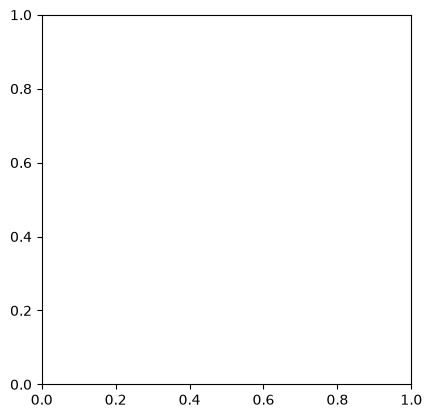

In [79]:
plt.pie(dataset_promedios["Promedio"], labels=dataset_promedios["Genero"], autopct= "%1.1f%%")
plt.title("Comparacion de Rating entre RPG e Indie")
plt.show()